# Credit Cart Clusturing

This project analyzes credit card usage patterns across 9,000 customers to create targeted marketing strategies, leveraging unsupervised machine learning through a structured pipeline that spans data exploration, feature scaling, PCA dimensionality reduction, clustering, and final business interpretation.

<img src='https://i.insider.com/5f107e392618b9717540e323?width=1200&format=jpeg' width='750'>

In [1]:
#Libraries
import pandas as pd
import numpy as np
import warnings 
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# EDA

In [2]:
df=pd.read_csv('CC GENERAL.csv')

In [3]:
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [4]:
df.tail()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
8945,C19186,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.50,6
8946,C19187,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,NaN,0.00,6
8947,C19188,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.25,6
8948,C19189,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.25,6
8949,C19190,372.708075,0.666667,1093.25,1093.25,0.00,127.040008,0.666667,0.666667,0.000000,0.333333,2,23,1200.0,63.165404,88.288956,0.00,6


In [5]:
df.shape

(8950, 18)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [7]:
df.isnull().sum().sort_values(ascending=False)

MINIMUM_PAYMENTS                    313
CREDIT_LIMIT                          1
CUST_ID                               0
BALANCE                               0
PRC_FULL_PAYMENT                      0
PAYMENTS                              0
PURCHASES_TRX                         0
CASH_ADVANCE_TRX                      0
CASH_ADVANCE_FREQUENCY                0
PURCHASES_INSTALLMENTS_FREQUENCY      0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_FREQUENCY                   0
CASH_ADVANCE                          0
INSTALLMENTS_PURCHASES                0
ONEOFF_PURCHASES                      0
PURCHASES                             0
BALANCE_FREQUENCY                     0
TENURE                                0
dtype: int64

In [8]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


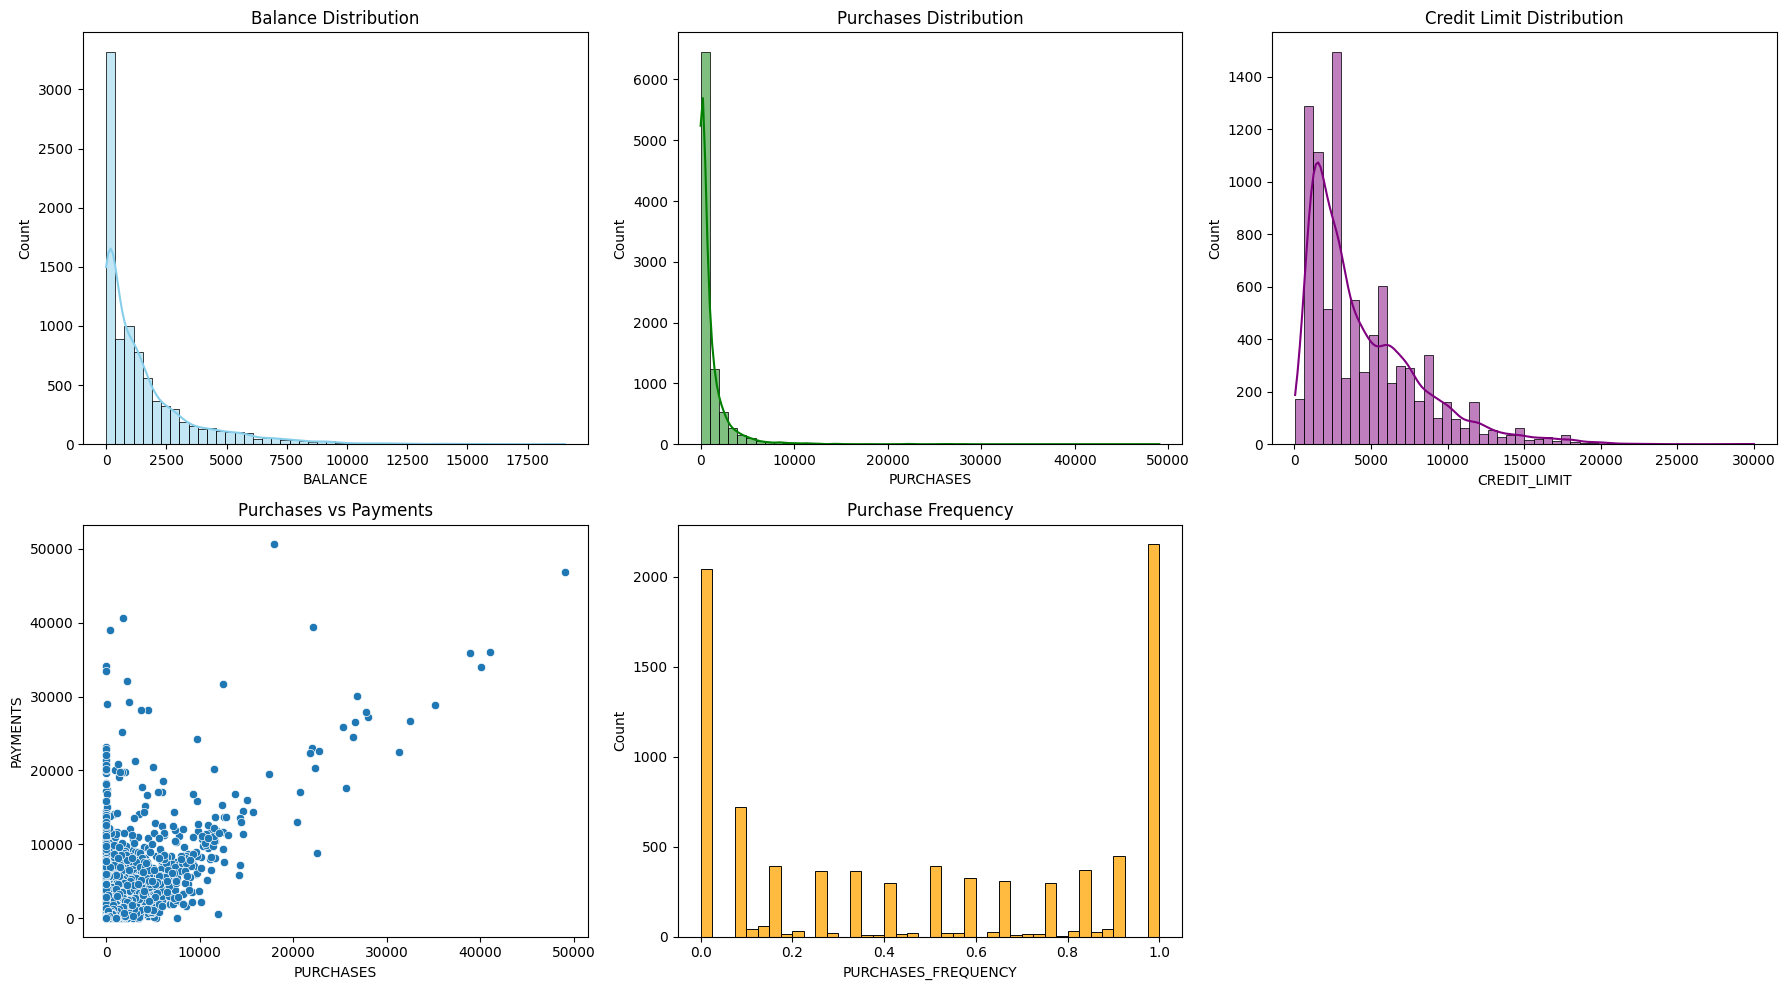

In [9]:
plt.figure(figsize=(18,10))

# Balance
plt.subplot(2,3,1)
sns.histplot(df["BALANCE"], bins=50, kde=True, color="skyblue")
plt.title("Balance Distribution")

# Purchases
plt.subplot(2,3,2)
sns.histplot(df["PURCHASES"], bins=50, kde=True, color="green")
plt.title("Purchases Distribution")

# Credit Limit
plt.subplot(2,3,3)
sns.histplot(df["CREDIT_LIMIT"], bins=50, kde=True, color="purple")
plt.title("Credit Limit Distribution")

# Purchases vs Payments
plt.subplot(2,3,4)
sns.scatterplot(x=df["PURCHASES"], y=df["PAYMENTS"])
plt.title("Purchases vs Payments")

# Purchase Frequency
plt.subplot(2,3,5)
sns.histplot(df["PURCHASES_FREQUENCY"], bins=40, color="orange")
plt.title("Purchase Frequency")

plt.tight_layout()
plt.show()

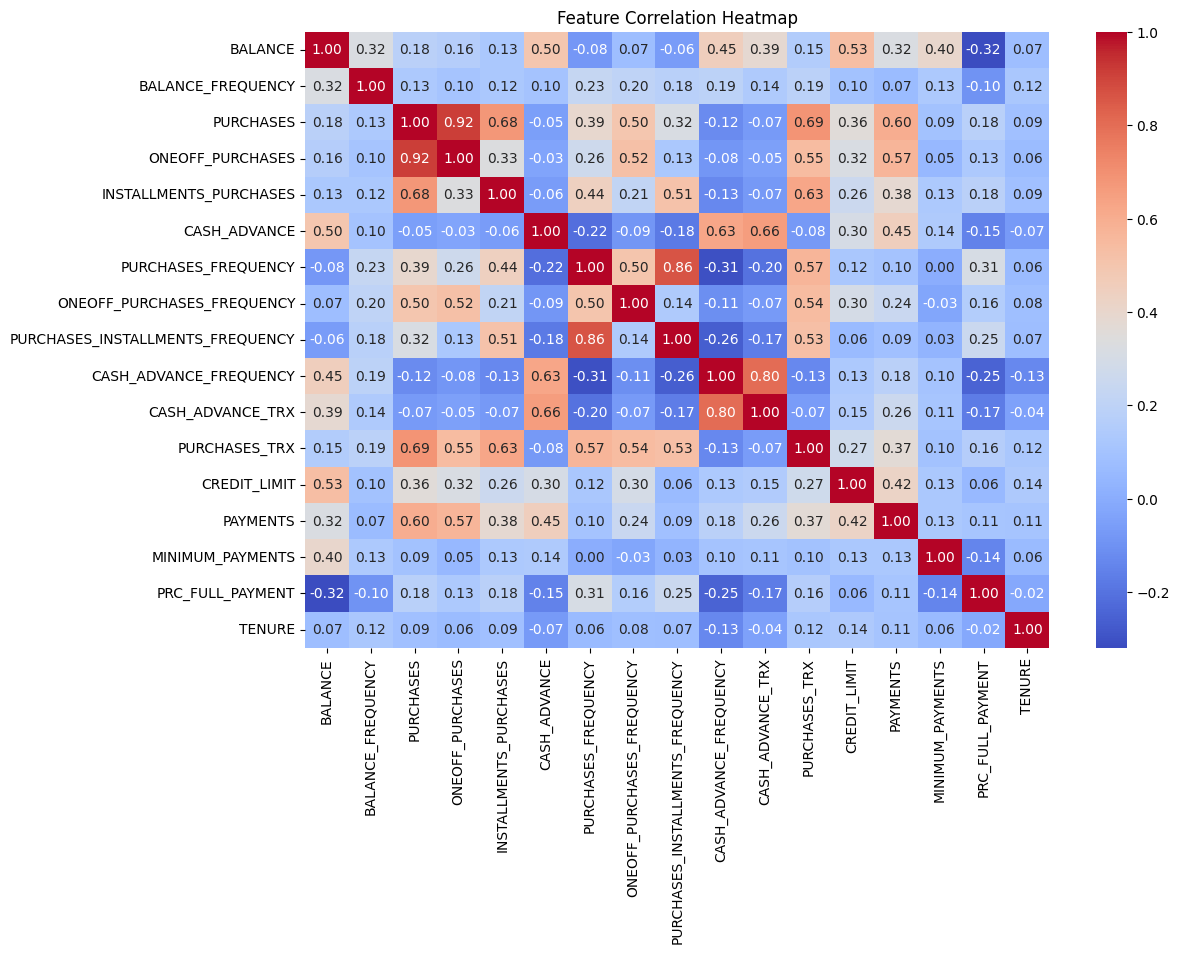

In [10]:
plt.figure(figsize=(12,8))
sns.heatmap(df.drop("CUST_ID", axis=1).corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

### Feature Engineering

In [11]:
df = df.drop('CUST_ID', axis=1)

In [12]:
df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median())

In [13]:
df["CREDIT_LIMIT"] = df["CREDIT_LIMIT"].fillna(df["CREDIT_LIMIT"].median())

In [14]:
df_fe = df.copy()
eps = 1.0  # divide-by-zero guard

df_fe["PURCHASES_PER_TRX"] = df_fe["PURCHASES"] / (df_fe["PURCHASES_TRX"] + eps)
df_fe["CASH_ADVANCE_PER_TRX"] = df_fe["CASH_ADVANCE"] / (df_fe["CASH_ADVANCE_TRX"] + eps)

df_fe["PAYMENT_TO_BALANCE"] = df_fe["PAYMENTS"] / (df_fe["BALANCE"] + eps)
df_fe["MINPAY_TO_BALANCE"] = df_fe["MINIMUM_PAYMENTS"] / (df_fe["BALANCE"] + eps)

df_fe["CASH_ADVANCE_SHARE"] = df_fe["CASH_ADVANCE"] / (df_fe["PURCHASES"] + df_fe["CASH_ADVANCE"] + eps)
df_fe["INSTALLMENT_SHARE"] = df_fe["INSTALLMENTS_PURCHASES"] / (df_fe["PURCHASES"] + eps)
df_fe["ONEOFF_SHARE"] = df_fe["ONEOFF_PURCHASES"] / (df_fe["PURCHASES"] + eps)

df_fe[[
    "PURCHASES_PER_TRX","CASH_ADVANCE_PER_TRX","PAYMENT_TO_BALANCE",
    "CASH_ADVANCE_SHARE","INSTALLMENT_SHARE","ONEOFF_SHARE"
]].describe().T

,count,mean,std,min,25%,50%,75%,max
PURCHASES_PER_TRX,8950.0,58.129748,107.141354,0.0,9.818229,35.872548,68.913654,4486.250000
CASH_ADVANCE_PER_TRX,8950.0,146.634111,316.148808,0.0,0.000000,0.000000,187.083026,7418.225705
PAYMENT_TO_BALANCE,8950.0,16.120941,205.549987,0.0,0.329309,1.400489,7.532226,14229.882480
CASH_ADVANCE_SHARE,8950.0,0.378811,0.442150,0.0,0.000000,0.000000,0.950476,0.999962
INSTALLMENT_SHARE,8950.0,0.400698,0.849339,0.0,0.000000,0.185036,0.969317,66.950000
ONEOFF_SHARE,8950.0,0.377199,0.423428,0.0,0.000000,0.109925,0.871232,1.798389


In [15]:
df_log = df_fe.copy()

for col in df_log.columns:
    df_log[col] = np.log1p(df_log[col])

In [16]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

x_scaled = scaler.fit_transform(df_log)

## PCA

In [22]:
from sklearn.decomposition import PCA

pca = PCA()

x_pca = pca.fit_transform(x_scaled)

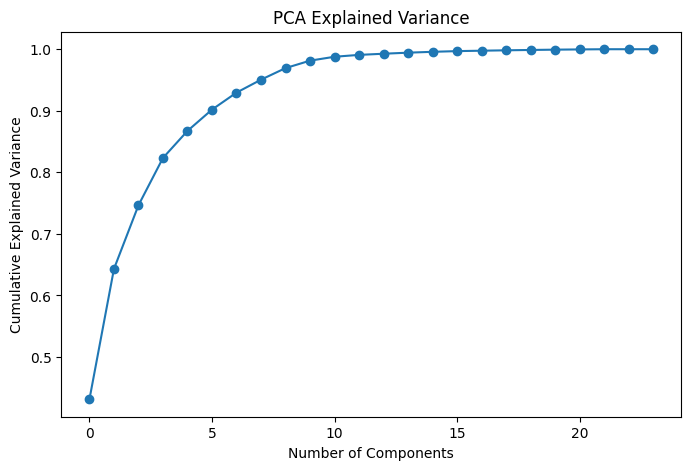

In [25]:
plt.figure(figsize=(8,5))

plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")

plt.title("PCA Explained Variance")

plt.show()

In [26]:
pca = PCA(n_components=3)

x_pca = pca.fit_transform(x_scaled)

x_pca = pd.DataFrame(x_pca, columns=["PC1","PC2","PC3"])

x_pca.head()

,PC1,PC2,PC3
0,-1.285009,-0.225545,-0.231156
1,1.090690,-2.088871,2.172498
2,1.762661,0.837573,-1.916574
3,-1.904328,-0.996777,-2.305055
4,1.299508,-0.774890,-0.064797


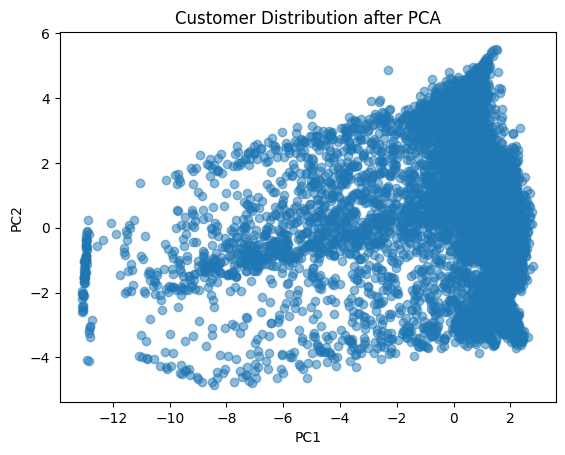

In [27]:
plt.scatter(x_pca["PC1"], x_pca["PC2"], alpha=0.5)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("Customer Distribution after PCA")

plt.show()

### Clustering K Means

In [28]:
wcss = []
ss = []

for i in range(2,10):
    
    model = KMeans(n_clusters=i, random_state=42, n_init=10)
    
    model.fit(x_scaled)
    
    tahmin = model.predict(x_scaled)
    
    # silhouette score
    ss1 = silhouette_score(x_scaled, tahmin)
    ss.append(ss1)
    
    print(f"Cluster {i} Silhouette Score:", ss1)
    
    # inertia = WCSS
    wcss.append(model.inertia_)

Cluster 2 Silhouette Score: 0.4431944341428987
Cluster 3 Silhouette Score: 0.25860039410177754
Cluster 4 Silhouette Score: 0.2999511942245884
Cluster 5 Silhouette Score: 0.29628701204010083
Cluster 6 Silhouette Score: 0.2624707437036074
Cluster 7 Silhouette Score: 0.2497261653341817
Cluster 8 Silhouette Score: 0.2518966582159788
Cluster 9 Silhouette Score: 0.25146510879425693


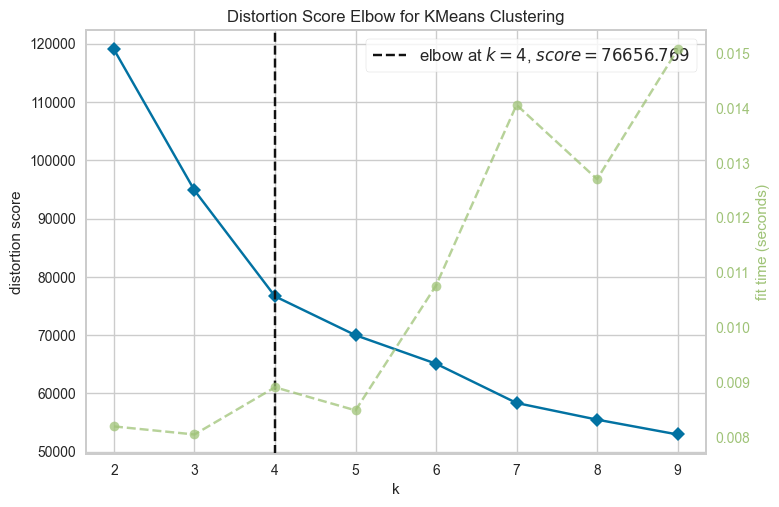

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [29]:
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans
vis = KElbowVisualizer(KMeans(), k=(2,10))

vis.fit(x_scaled)

vis.show()

### Model Training (K-Means Clustering)

In [30]:
model = KMeans(n_clusters=3, random_state=42, n_init=10)

clusters = model.fit_predict(x_scaled)

df_log["cluster"] = clusters

In [32]:
df_log["cluster"].value_counts()

cluster
1    5274
2    2429
0    1247
Name: count, dtype: int64

In [33]:
df_cluster = df.copy()
df_cluster["cluster"] = clusters

df_cluster.groupby("cluster").mean()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
cluster,,,,,,,,,,,,,,,,,
0,98.854052,0.351056,347.095365,198.447939,149.208372,339.287088,0.292528,0.068749,0.217629,0.036872,0.813152,4.704090,3707.890493,1191.621280,177.968350,0.232522,11.340818
1,1432.633161,0.963652,1596.198043,943.084702,653.467050,525.636819,0.731751,0.314614,0.549468,0.074957,1.761851,23.369928,4716.357125,1868.066704,870.404759,0.195078,11.614524
2,2603.158260,0.959861,52.493561,33.355772,19.187880,2291.312010,0.067765,0.027581,0.038055,0.316277,7.727872,1.043228,4415.817708,1718.197589,1131.936736,0.023445,11.396871


This project applied clustering techniques to segment credit card customers based on financial behavior.

After preprocessing, scaling, and dimensionality exploration using PCA, K-Means clustering with three clusters was selected as the optimal approach.

The resulting segments reveal meaningful behavioral differences among customers and provide actionable insights for marketing strategies, credit risk analysis, and customer relationship management.